# Elmer Capacitance Extraction of an Interdigital Capacitor

::::{admonition} Required extras
:class: tip

This notebook needs the `models` extra and the Elmer driver from `gplugins`:

```bash
uv add "qpdk[models]" "gplugins[elmer] @ git+https://github.com/gdsfactory/gplugins.git@4ac6063ebfc01473a2f514b460d6f3ff04f5a17d"
# or with pip:
pip install "qpdk[models]" "gplugins[elmer] @ git+https://github.com/gdsfactory/gplugins.git@4ac6063ebfc01473a2f514b460d6f3ff04f5a17d"
```

The Elmer driver changes are currently in the companion
[gplugins pull request](https://github.com/gdsfactory/gplugins/pull/781); the install
commands pin the revision tested with this notebook until a release includes it.

**Elmer is an external solver.** `ElmerGrid` and `ElmerSolver` must be available on your
`PATH`; `ElmerSolver_mpi` is also needed when `QPDK_ELMER_PROCESSES` exceeds 1. They
are not pip-installable. See the
[Elmer FEM installation guide](https://www.elmerfem.org/blog/binaries/) for binaries and
container options.

See the {ref}`extras reference <notebook-extras>` for what each qpdk extra installs.
::::

This notebook runs a quasi-static electrostatic solve with Elmer FEM to extract the
capacitance of a QPDK interdigital capacitor. Elmer solves
$\nabla \cdot (\epsilon \nabla \phi) = 0$ with a fixed potential on each metal
terminal. Elmer's `.dat` result is the lumped (circuit) capacitance matrix;
`gplugins` converts it to a Maxwell matrix, with negative off-diagonal entries, in
`ElectrostaticResults`.

The reported number comes from a mesh-convergence study. The geometry, the layer stack
and the simulation domain are held fixed, the mesh is refined over five factors, and
the finest mesh supplies the final value. A separate lateral-pad comparison checks how
much that value depends on the outer boundary of the finite domain.

The saved output uses cubic elements and a 0.5 % refinement check. CI separately
executes the notebook with quadratic elements and a 3 % check when `GITHUB_ACTIONS`
is set. Set `QPDK_ELMER_CI_FAST=1` to use that profile locally. The cubic
profile is memory intensive; use the CI smoke profile for a quick functional run.

## Physics

An interdigital capacitor (IDC) is two interleaved combs of metal fingers. Each comb is
a separate conductor (terminal), and the capacitance we care about is the coupling
between them.

For $N$ conductors Elmer's `.dat` result is the lumped (circuit) capacitance
matrix. `gplugins` converts it to the Maxwell form $C$ reported in
`ElectrostaticResults`, defined by $Q_i = \sum_j C_{ij} V_j$ with negative
off-diagonal entries:

$$ C_{ij} = -C_{ij}^{\text{mutual}} \quad (i \neq j). $$

So for a two-terminal device the mutual capacitance is
$C_{12}^{\text{mutual}} = -C_{12}$, and it shows up as a **negative** off-diagonal
entry. This model has **no grounded conductor**: the diagonal entries are not independent
capacitances-to-ground, and $C_{11}$ and $C_{22}$ are effectively equal to the
mutual $|C_{12}|$. All Elmer output is in SI units (farads); we convert to
femtofarads below.

This is a 3D FEM result only. It is **not benchmarked against an analytic IDC model**,
and no analytic formula is evaluated here. The check below compares the last two
mesh results; their difference is not a bound on absolute model error.

## Setup and Imports

In [1]:
import sys

if "google.colab" in sys.modules:
    import subprocess

    print("Running in Google Colab. Installing QPDK...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "qpdk[models] @ git+https://github.com/gdsfactory/quantum-rf-pdk.git",
        "gplugins[elmer] @ git+https://github.com/gdsfactory/gplugins.git@4ac6063ebfc01473a2f514b460d6f3ff04f5a17d",
    ])

In [2]:
# CI executes this notebook headless with MPLBACKEND=Agg, which would drop the
# convergence figure from the saved output, so pin the backend that renders figures
# inline.
import matplotlib

matplotlib.use("module://matplotlib_inline.backend_inline")

In [3]:
import os
import tempfile
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import gdsfactory as gf
import numpy as np
from gplugins.elmer import run_capacitive_simulation_elmer
from matplotlib import pyplot as plt
from meshwell.resolution import ConstantInField

from qpdk import PDK
from qpdk.cells.capacitor import interdigital_capacitor
from qpdk.tech import LAYER, material_properties

PDK.activate()

## Simulation Geometry

We use the QPDK `interdigital_capacitor` geometry with
a small number of fingers to keep the mesh and solve affordable.

Two details matter for a valid capacitance extraction:

1. **Two isolated terminals.** The capacitor must present two disconnected metal
   polygons. QPDK's IDC draws its metal on `M1_DRAW` (the additive mask) and an
   enclosing rectangle on `M1_ETCH` (the subtractive mask). We draw the two combs
   without that enclosure, then etch the entire `SIM_AREA`. QPDK's derived `M1` rule
   is `SIM_AREA - (M1_ETCH - M1_DRAW)`, so its remaining metal is exactly the two combs.
2. **A domain outline for the dielectrics.** The substrate and air prisms are built from
   the same outline on the non-fabrication `SIM_AREA` layer.

The lateral pad is fixed for the whole study at `domain_pad=90.0` μm, which puts the
outer boundary well away from the finger gaps where the coupling lives. The outer
substrate and vacuum faces use Elmer's natural zero-normal-flux boundary condition, so
the finite domain still affects the extracted value; the lateral-pad comparison below
quantifies that effect separately from mesh convergence.

Bounding box: (-108,-103;108,103)
Terminals: ['o1', 'o2']


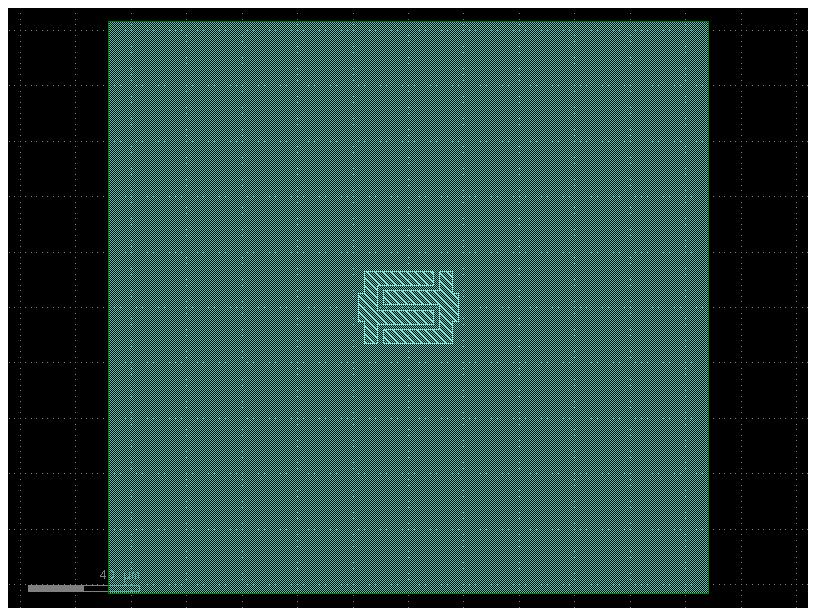

In [4]:
@gf.cell
def interdigital_capacitor_for_elmer(
    fingers: int = 4,
    finger_length: float = 20.0,
    finger_gap: float = 2.0,
    thickness: float = 5.0,
    domain_pad: float = 90.0,
) -> gf.Component:
    """Two-terminal IDC with PDK mask layers for metal and dielectric prisms.

    Args:
        fingers: Total number of interleaved fingers.
        finger_length: Length of each finger in μm.
        finger_gap: Gap between adjacent fingers in μm.
        thickness: Finger width in μm.
        domain_pad: Lateral padding of the simulation outline around the metal in μm.

    Returns:
        Component with two isolated `M1_DRAW` terminals (ports ``o1`` and ``o2``) and
        coincident `SIM_AREA` and `M1_ETCH` rectangles.
    """
    c = gf.Component()
    idc = c << interdigital_capacitor(
        fingers=fingers,
        finger_length=finger_length,
        finger_gap=finger_gap,
        thickness=thickness,
        etch_layer=None,  # keep the two combs as separate M1_DRAW polygons
    )
    c.add_ports(idc.ports)

    # Flatten so the terminals are plain polygons in one cell, as the mesher expects.
    c.flatten()
    domain = c.bbox().enlarged(domain_pad, domain_pad)
    c.kdb_cell.shapes(LAYER.SIM_AREA).insert(domain)
    c.kdb_cell.shapes(LAYER.M1_ETCH).insert(domain)
    return c


component = interdigital_capacitor_for_elmer()
component.plot()
print(f"Bounding box: {component.bbox()}")
print(f"Terminals: {[port.name for port in component.ports]}")

## Layer Stack and Materials

We start from `PDK.layer_stack`, which the Palace capacitor optimization notebook
also uses. We retain the three levels needed here, including the derived `M1` rule.
The PDK specifies the Nb film thickness and material. We reduce the substrate and
vacuum heights to $60\,\text{μm}$ and $40\,\text{μm}$ for this finite simulation
domain; both are $500\,\text{μm}$ in the full PDK stack. The vacuum starts at the
substrate surface to fill the gaps beside
the film; [meshwell](https://github.com/simbilod/meshwell) cuts the higher-priority
metal out of that prism. We check lateral-domain sensitivity below, but do not
quantify the effect of these vertical truncations.

Material permittivities come from the QPDK technology definition
(`qpdk.tech.material_properties`): Si uses $\epsilon_{\mathrm{r}} = 11.45$, and the niobium
film is treated as a perfect conductor.

In [5]:
layer_stack = PDK.layer_stack.model_copy(deep=True)
layer_stack.layers = {
    name: layer_stack.layers[name] for name in ("M1", "Substrate", "Vacuum")
}
layer_stack.layers["Substrate"].zmin = -60.0
layer_stack.layers["Substrate"].thickness = 60.0
layer_stack.layers["Vacuum"].zmin = 0.0
layer_stack.layers["Vacuum"].thickness = 40.0

material_spec = material_properties

print("Layer stack:")
for name, level in layer_stack.layers.items():
    print(
        f"  {name:>9}: z = {level.zmin:+.2f} … {level.zmin + level.thickness:+.2f} µm, "
        f"material = {level.material}"
    )

Layer stack:
         M1: z = +0.00 … +0.20 µm, material = Nb
  Substrate: z = -60.00 … +0.00 µm, material = Si
     Vacuum: z = +0.00 … +40.00 µm, material = vacuum


## Mesh Settings

`mesh_parameters` is forwarded to [meshwell's mesh function](https://simbilod.github.io/meshwell/02_intro_meshwell.html#cad-mesh).
Its [`resolution_specs` API](https://simbilod.github.io/meshwell/21_resolution_advanced.html)
maps each physical prism name to a list of resolution objects. The driver splits
the PDK metal into `M1@o1` and `M1@o2`. [`ConstantInField`](https://simbilod.github.io/meshwell/20_resolution_basic.html)
pins a uniform element size. The
metal surfaces are meshed finely because the finger gaps (2 μm) carry most of the
coupling; the bulk dielectric only needs to resolve the field far from the metal.

`BASE_MESH_LENGTHS_UM` holds the nominal (factor 1.0) lengths, and
`mesh_parameters_for_factor` scales every one of them by the same factor: a smaller
factor refines the whole mesh uniformly, while the geometry, the layer stack and the
domain stay untouched.

In [6]:
BASE_MESH_LENGTHS_UM = {
    "default": 8.0,  # μm, everywhere not covered by a more specific spec
    "terminal": 0.5,  # μm, terminal edges and faces
    "dielectric_surfaces": 3.0,  # μm, substrate and vacuum interfaces
    "dielectric_volumes": 8.0,  # μm, substrate and vacuum bulk
}


def mesh_parameters_for_factor(mesh_factor: float) -> dict[str, Any]:
    """Mesh parameters with every base length scaled by ``mesh_factor``.

    Args:
        mesh_factor: Multiplier applied to all mesh lengths. ``1.0`` is the nominal
            mesh, smaller values refine it.

    Returns:
        Keyword arguments for :func:`meshwell.mesh.mesh`.

    Raises:
        ValueError: If ``mesh_factor`` is not positive.
    """
    if not mesh_factor > 0:
        raise ValueError(f"mesh_factor must be positive, got {mesh_factor}")

    scaled = {
        name: length * mesh_factor for name, length in BASE_MESH_LENGTHS_UM.items()
    }
    resolution_specs: dict[str, list[ConstantInField]] = {}
    for terminal in ("M1@o1", "M1@o2"):
        resolution_specs[terminal] = [
            ConstantInField(resolution=scaled["terminal"], apply_to="curves"),
            ConstantInField(resolution=scaled["terminal"], apply_to="surfaces"),
        ]
    for dielectric in ("Substrate", "Vacuum"):
        resolution_specs[dielectric] = [
            ConstantInField(
                resolution=scaled["dielectric_surfaces"], apply_to="surfaces"
            ),
            ConstantInField(
                resolution=scaled["dielectric_volumes"], apply_to="volumes"
            ),
        ]
    return {
        "default_characteristic_length": scaled["default"],
        "resolution_specs": resolution_specs,
        "background_tag": "Vacuum",
    }


nominal_mesh = mesh_parameters_for_factor(1.0)
print(
    f"Nominal default characteristic length: "
    f"{nominal_mesh['default_characteristic_length']:.2f} µm"
)
for prism, specs in nominal_mesh["resolution_specs"].items():
    sizes = ", ".join(f"{spec.resolution:.2f} µm ({spec.apply_to})" for spec in specs)
    print(f"  {prism:>10}: {sizes}")

Nominal default characteristic length: 8.00 µm
       M1@o1: 0.50 µm (curves), 0.50 µm (surfaces)
       M1@o2: 0.50 µm (curves), 0.50 µm (surfaces)
   Substrate: 3.00 µm (surfaces), 8.00 µm (volumes)
      Vacuum: 3.00 µm (surfaces), 8.00 µm (volumes)


## Solve at Each Mesh Factor

Every solve below uses the same component, layer stack, materials and domain; only the
mesh factor changes. The run profile controls these settings:

- Finite element order is the polynomial degree of the basis used to approximate the
  potential within an element; see [MFEM's basis-function reference](https://mfem.org/basis-functions/).
  The saved study uses cubic (`element_order=3`) functions; CI uses quadratic
  (`element_order=2`). A
  first-order solve on a coarse mesh is not a reliable capacitance number.
- `QPDK_ELMER_PROCESSES` selects MPI ranks for the default profile (1 by default).
  CI runs serially.
- The default profile raises the linear-iteration cap to 3500: the cubic basis needs more
  iterations per solve than the driver's default of 500, which CI keeps.

`solve_idc` runs one solve into a fresh scratch directory and returns the Maxwell
matrix in fF together with the mutual capacitance. Each port becomes a terminal held at
a fixed potential; both combs carry a port, so no metal surface is grounded and the
model has no grounded conductor.

In [7]:
IS_CI = (
    os.environ.get("GITHUB_ACTIONS") == "true"
    or os.environ.get("QPDK_ELMER_CI_FAST") == "1"
)
RUN_MODE = "CI smoke" if IS_CI else "high accuracy"
MESH_FACTORS = (1.0, 0.75, 0.6, 0.5) if IS_CI else (0.5, 0.4, 0.35, 0.3, 0.25)
ELEMENT_ORDER = 2 if IS_CI else 3
CONVERGENCE_TOLERANCE = 0.03 if IS_CI else 0.005
MAX_LINEAR_ITERATIONS = 500 if IS_CI else 3500
N_PROCESSES = 1 if IS_CI else int(os.environ.get("QPDK_ELMER_PROCESSES", "1"))

print(
    f"Elmer notebook run mode: {RUN_MODE} "
    f"(element_order={ELEMENT_ORDER}, "
    f"tolerance={100 * CONVERGENCE_TOLERANCE:.1f} %, "
    f"n_processes={N_PROCESSES})"
)


@dataclass(slots=True, frozen=True)
class MeshSolve:
    """One independently remeshed electrostatic solve."""

    label: str
    mesh_factor: float
    capacitance_ff: np.ndarray
    mutual_ff: float


def solve_idc(component: gf.Component, mesh_factor: float, label: str) -> MeshSolve:
    """Solve the capacitor on a mesh scaled by ``mesh_factor``.

    Args:
        component: Two-terminal IDC component carrying a `SIM_AREA` outline.
        mesh_factor: Multiplier on every base mesh length; smaller is finer.
        label: Name for this solve, used in tables and error messages.

    Returns:
        The Maxwell capacitance matrix in fF and the extracted mutual capacitance.

    Raises:
        ValueError: If the component ports are not named ``o1`` and ``o2``.
    """
    simulation_folder = Path(
        tempfile.mkdtemp(prefix="qpdk_elmer_interdigital_capacitor_")
    )
    print(f"{label}: solving")
    results = run_capacitive_simulation_elmer(
        component,
        element_order=ELEMENT_ORDER,
        n_processes=N_PROCESSES,
        layer_stack=layer_stack,
        material_spec=material_spec,
        simulation_folder=simulation_folder,
        mesh_parameters=mesh_parameters_for_factor(mesh_factor),
        simulator_params={"linear_system_max_iterations": MAX_LINEAR_ITERATIONS},
    )

    terminals = tuple(port.name for port in component.ports)
    if terminals != ("o1", "o2"):
        raise ValueError(f"{label}: unexpected terminals {terminals}")
    capacitance_ff = (
        np.array([
            [results.capacitance_matrix[i, j] for j in terminals] for i in terminals
        ])
        * 1e15
    )  # F -> fF
    return MeshSolve(
        label=label,
        mesh_factor=mesh_factor,
        capacitance_ff=capacitance_ff,
        mutual_ff=-float(capacitance_ff[0, 1]),
    )

Elmer notebook run mode: high accuracy (element_order=3, tolerance=0.5 %, n_processes=32)


In [8]:
mesh_results = [
    solve_idc(component, factor, f"mesh factor {factor:g}") for factor in MESH_FACTORS
]

mesh factor 0.5: solving
MAIN: *** Elmer Solver: ALL DONE ***
mesh factor 0.4: solving
MAIN: *** Elmer Solver: ALL DONE ***
mesh factor 0.35: solving
MAIN: *** Elmer Solver: ALL DONE ***
mesh factor 0.3: solving
MAIN: *** Elmer Solver: ALL DONE ***
mesh factor 0.25: solving
MAIN: *** Elmer Solver: ALL DONE ***


## Capacitance Matrix

The Maxwell capacitance matrix is assembled in the component's port order, so the
terminals are exactly `o1` and `o2`. The final reported value is the one from the
finest mesh, which is the last element of `mesh_results`.

In [9]:
finest = mesh_results[-1]
terminals = tuple(port.name for port in component.ports)

print("Final Maxwell capacitance matrix (fF):")
print(finest.capacitance_ff)
print(f"\nCapacitance matrix indexed by {terminals}")

Final Maxwell capacitance matrix (fF):
[[ 8.13157236 -8.13157236]
 [-8.13157236  8.13157236]]

Capacitance matrix indexed by ('o1', 'o2')


The off-diagonal entry is negative by the Maxwell convention
($C_{ij} = -C_{ij}^{\text{mutual}}$), so the mutual capacitance between the two
combs is its negative. There is no grounded conductor, so $C_{11}$ and
$C_{22}$ are not independent capacitances-to-ground; we report the mutual value.

In [10]:
print(f"Final off-diagonal C12: {finest.capacitance_ff[0, 1]:.3f} fF")
print(f"Final mutual capacitance C12_mutual = -C12: {finest.mutual_ff:.3f} fF")
print(
    f"Final reported mutual capacitance: {finest.mutual_ff:.3f} fF "
    f"(element_order={ELEMENT_ORDER}, mesh factor {finest.mesh_factor:g})"
)

Final off-diagonal C12: -8.132 fF
Final mutual capacitance C12_mutual = -C12: 8.132 fF
Final reported mutual capacitance: 8.132 fF (element_order=3, mesh factor 0.25)


## Mesh Convergence

The five saved solves are **independent remeshes**, not Elmer nonlinear iteration
counts: their factors are 0.5, 0.4, 0.35, 0.3 and 0.25. CI uses the coarser
factors 1.0, 0.75, 0.6 and 0.5. Nothing is continued from one solve to the next, and no field
solution is reused, so the pass number is only an index into the refinement sequence.

The upper panel shows the extracted mutual capacitance, the lower panel the absolute
relative change from the previous pass, and the table lists the same two numbers. Both
final changes staying below `CONVERGENCE_TOLERANCE` (0.5 % in the saved run, 3 % in
CI) provides a practical refinement check, not an absolute error bound. Independent
remeshes need not change the result monotonically.

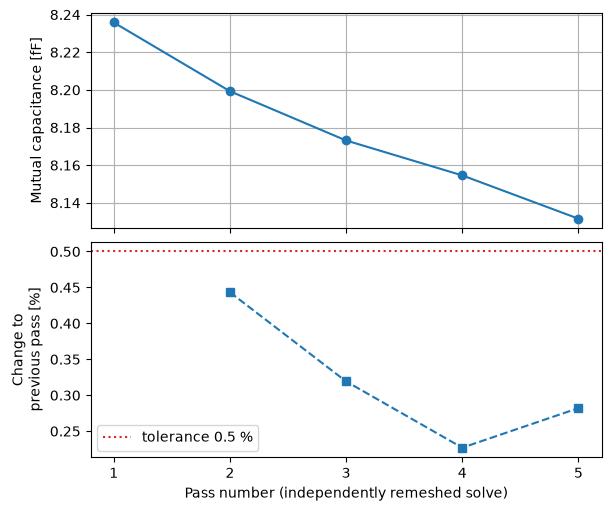

pass  factor  C_mutual_fF  change_pct
   1     0.5        8.236         n/a
   2     0.4        8.199       0.443
   3    0.35        8.173       0.319
   4     0.3        8.155       0.227
   5    0.25        8.132       0.282
Mesh convergence check passed: final changes 0.227 % and 0.282 % <= tolerance 0.5 %


In [11]:
passes = np.arange(1, len(mesh_results) + 1)
mutual_ff = np.array([result.mutual_ff for result in mesh_results])
relative_change = np.full(mutual_ff.shape, np.nan)
relative_change[1:] = np.abs(np.diff(mutual_ff)) / mutual_ff[:-1]

_, (ax_value, ax_change) = plt.subplots(
    2, 1, sharex=True, figsize=(6.0, 5.0), layout="constrained"
)
ax_value.plot(passes, mutual_ff, marker="o")
ax_value.set_ylabel("Mutual capacitance [fF]")
ax_value.grid(True)

ax_change.plot(passes[1:], 100 * relative_change[1:], marker="s", linestyle="--")
ax_change.axhline(
    100 * CONVERGENCE_TOLERANCE,
    color="tab:red",
    linestyle=":",
    label=f"tolerance {100 * CONVERGENCE_TOLERANCE:.1f} %",
)
ax_change.set_xticks(passes)
ax_change.set_xlabel("Pass number (independently remeshed solve)")
ax_change.set_ylabel("Change to\nprevious pass [%]")
ax_change.legend()
plt.show()

print(f"{'pass':>4} {'factor':>7} {'C_mutual_fF':>12} {'change_pct':>11}")
for index, result in enumerate(mesh_results, start=1):
    change = relative_change[index - 1]
    change_text = "n/a" if np.isnan(change) else f"{100 * change:.3f}"
    print(
        f"{index:>4} {result.mesh_factor:>7g} {result.mutual_ff:>12.3f} {change_text:>11}"
    )

final_changes = relative_change[-2:]
if not (final_changes <= CONVERGENCE_TOLERANCE).all():
    raise ValueError(
        f"the last two mesh refinements changed the mutual capacitance by "
        f"{100 * final_changes[0]:.3f} % and {100 * final_changes[1]:.3f} %, "
        f"above CONVERGENCE_TOLERANCE = "
        f"{100 * CONVERGENCE_TOLERANCE:.1f} %; refine the mesh further"
    )
print(
    f"Mesh convergence check passed: final changes "
    f"{100 * final_changes[0]:.3f} % and {100 * final_changes[1]:.3f} % "
    f"<= tolerance {100 * CONVERGENCE_TOLERANCE:.1f} %"
)

## Lateral Domain Sensitivity

Mesh convergence above holds the domain fixed at `domain_pad=90.0` μm. This separate
check asks how much the extracted value depends on the outer boundary: we rebuild the
same capacitor with a 60 μm lateral pad, keep the active profile's element order and
reuse the finest mesh factor, and compare against the pad-90 μm result from the final
pass.

Changing the pad also changes the mesh, so the difference mixes the domain effect with
a discretization effect. This is a sensitivity check between two finite domains: it is
**not** a proof that the 90 μm boundary is converged to an infinite domain, and it says
nothing about vertical truncation or absolute accuracy.

In [12]:
component_narrow = interdigital_capacitor_for_elmer(domain_pad=60.0)
narrow = solve_idc(component_narrow, finest.mesh_factor, "pad 60 μm, finest mesh")
wide = finest

print(f"Mutual capacitance at domain_pad=60.0 μm: {narrow.mutual_ff:.3f} fF")
print(f"Mutual capacitance at domain_pad=90.0 μm: {wide.mutual_ff:.3f} fF")
domain_change = abs(wide.mutual_ff - narrow.mutual_ff) / narrow.mutual_ff
print(f"Relative change: {domain_change:.2%}")
if domain_change > 0.01:
    raise ValueError(f"lateral-pad check changed capacitance by {domain_change:.2%}")
print("Lateral-domain sensitivity check passed: change <= 1 %")

pad 60 μm, finest mesh: solving
MAIN: *** Elmer Solver: ALL DONE ***
Mutual capacitance at domain_pad=60.0 μm: 8.126 fF
Mutual capacitance at domain_pad=90.0 μm: 8.132 fF
Relative change: 0.07%
Lateral-domain sensitivity check passed: change <= 1 %


## Sanity Checks

Every solve must give a finite, symmetric Maxwell matrix with a positive diagonal,
negative off-diagonal and near-zero row sums. With no grounded conductor, `C11` and
`C22` duplicate the mutual term. The broad 5-40 fF range is a regression guard against
order-of-magnitude errors, not a claim about model accuracy.

In [13]:
for result in (*mesh_results, narrow):
    matrix = result.capacitance_ff
    if not np.isfinite(matrix).all():
        raise ValueError(f"{result.label}: matrix has non-finite entries")
    if not np.allclose(matrix, matrix.T, rtol=1e-2, atol=1e-3):
        raise ValueError(f"{result.label}: matrix is not symmetric")
    if not (np.diag(matrix) > 0).all():
        raise ValueError(f"{result.label}: matrix diagonal must be positive")
    if matrix[0, 1] >= 0 or matrix[1, 0] >= 0:
        raise ValueError(f"{result.label}: Maxwell off-diagonals must be negative")
    if not 5.0 < result.mutual_ff < 40.0:
        raise ValueError(
            f"{result.label}: mutual capacitance outside 5-40 fF: {result.mutual_ff}"
        )
    if (np.abs(matrix.sum(axis=1)) > 0.01 * result.mutual_ff).any():
        raise ValueError(f"{result.label}: matrix has nonzero row sums")

print("All checks passed.")

All checks passed.


In [14]:
import hashlib

from IPython import get_ipython

executed_code = get_ipython().history_manager.input_hist_raw[1:-1]
code_digest = hashlib.sha256(
    "\0".join(source.rstrip() for source in executed_code).encode()
).hexdigest()
print(f"Executed code SHA256: {code_digest}")

Executed code SHA256: b090df573c52af23f46efa45b54f25331a6da98292baef35e441fef9d82bc547


## Summary

We extracted the quasi-static capacitance of a QPDK interdigital capacitor with Elmer in
the default high accuracy profile (cubic elements, 0.5 % refinement tolerance) and report
the value from the finest mesh of the convergence study:

- Built a two-terminal geometry from `qpdk.cells.capacitor.interdigital_capacitor`,
  etching `SIM_AREA` except for the two `M1_DRAW` combs, and using the PDK's derived
  `M1` level for both terminals.
- Fixed the domain at a 90 μm lateral pad with a 60 μm substrate and a 40 μm vacuum,
  and solved with cubic (third-order) elements on five independently generated meshes
  (factors 0.5, 0.4, 0.35, 0.3, 0.25).
- Converted Elmer's lumped result to the 2x2 Maxwell matrix and took the mutual
  capacitance $-C_{12}$ from each solve. With no grounded conductor, `C11` and `C22`
  are not independent capacitances-to-ground.
- Required both final successive changes to stay below the named 0.5 % tolerance, and
  reported the finest-mesh value as the result.
- Required the 60 μm against 90 μm lateral-pad comparison at the finest mesh to change
  the value by no more than 1 %, as a finite-domain sensitivity check.

The result is a 3D FEM number only, not benchmarked against an analytic IDC model. The
refinement tolerance measures change between meshes, not absolute accuracy, and the
lateral-pad comparison is a sensitivity check between two finite domains, not a
convergence proof for an unbounded one. Vertical truncation is not checked here.

CI executes this notebook fresh in the CI smoke profile (quadratic elements, 3 %
tolerance) to check that the pipeline still runs end to end. It does not reproduce the
numbers above.

The same layout can be swept or optimized by varying `fingers`, `finger_length` and
`finger_gap` in `interdigital_capacitor_for_elmer` and re-running the solve.